### 数据集

In [55]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
np.random.seed(666)
x = np.random.uniform(-3, 3, size=100)
y = 0.5 * x**2 + x + 2 + np.random.normal(0, 1, size=100)  # 根据二次函数生成目标值，并加入均值为 0、标准差为 1 的随机噪声
X = x.reshape(-1, 1)  # 将一维数组转换为二维特征矩阵，供 sklearn 模型使用

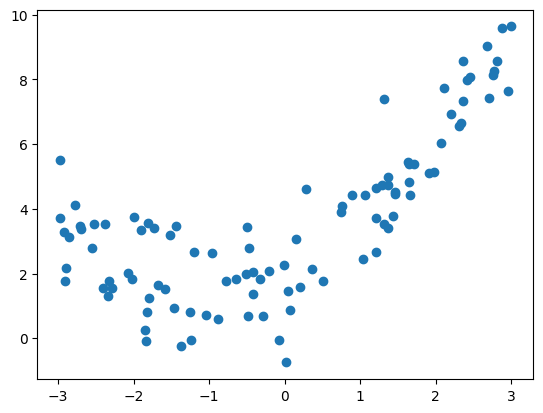

In [57]:
plt.scatter(X, y)
plt.show()

### LinearSVR

In [58]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [59]:
def StandardLinearSVR(epsilon=0.1):     # 创建“标准化 + LinearSVR”的回归流程
    return Pipeline([
        ("std_scaler", StandardScaler()),                # 对特征进行标准化，使均值为 0、标准差为 1
        ("linearSVR", LinearSVR(epsilon=epsilon, C=1))   # 创建线性 SVR，epsilon 控制 ε-不敏感区域宽度
    ])

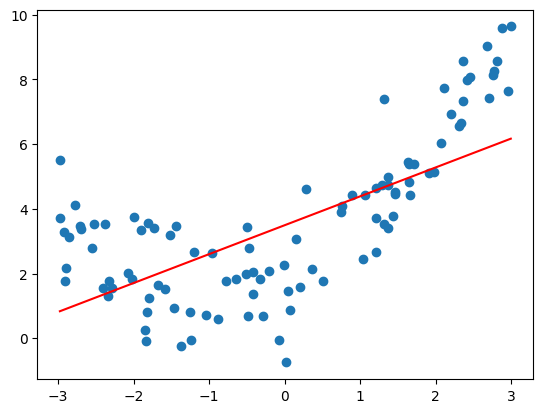

In [60]:
svr = StandardLinearSVR()
svr.fit(X, y)
y_predict = svr.predict(X)
plt.scatter(x, y)
plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r')  # 按 x 从小到大排序，并绘制对应的预测结果，避免折线连接顺序混乱
plt.show()

In [61]:
svr.score(X, y)

0.48764762540009954

### SVR (support vector regression)

In [62]:
from sklearn.svm import SVR

In [63]:
def StandardSVR(epsilon=0.1):     # 创建“标准化 + LinearSVR”的回归流程
    return Pipeline([
        ("std_scaler", StandardScaler()),                  # 对特征进行标准化，使均值为 0、标准差为 1
        ("SVR", SVR(kernel="rbf", epsilon=epsilon, C=1))   # 创建SVR
    ])

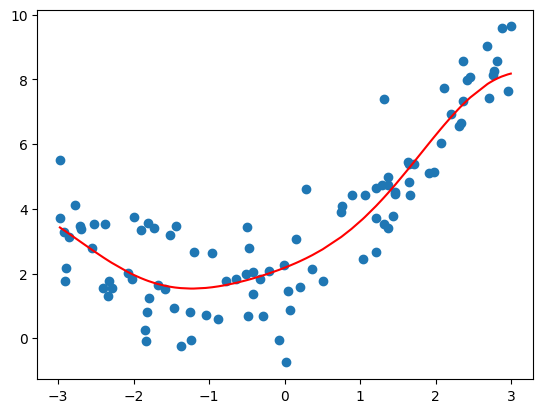

In [64]:
svr = StandardSVR()
svr.fit(X, y)
y_predict = svr.predict(X)
plt.scatter(x, y)
plt.plot(np.sort(x), y_predict[np.argsort(x)], color='r')  # 按 x 从小到大排序，并绘制对应的预测结果，避免折线连接顺序混乱
plt.show()

In [65]:
svr.score(X, y)

0.8138647789256848